# **Perform EDA And Data quality checks**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

fact_sales = pd.read_csv(r"C:\Users\rocky\Desktop\ForeSight\data\processed\fact_sales_daily.csv", 
                         parse_dates=["Date"])
fact_inv   = pd.read_csv(r"C:\Users\rocky\Desktop\ForeSight\data\processed\fact_inventory.csv", 
                         parse_dates=["Snapshot_Date"])

**Quick stats overview**

In [9]:
fact_sales.describe()

,Date,Units_Sold,Revenue,Price,Promotion,year,month,week,is_weekend,is_holiday,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
count,36550,36550.000000,36550.00000,36550.000000,36550.000000,36550.000000,36550.000000,36550.000000,36550.000000,36550.000000,36550.000000,36550.000000,36550.00000
mean,2024-12-31 00:00:00,14.003010,84707.43385,5892.663800,0.102599,2024.499316,6.519836,26.395349,0.284542,0.010944,3770.729400,5892.663800,2121.93440
min,2024-01-01 00:00:00,0.000000,0.00000,663.460000,0.000000,2024.000000,1.000000,1.000000,0.000000,0.000000,307.060000,663.460000,-5484.32000
25%,2024-07-01 00:00:00,7.000000,27643.70000,3484.090000,0.000000,2024.000000,4.000000,13.000000,0.000000,0.000000,1913.030000,3484.090000,-681.48000
50%,2024-12-31 00:00:00,13.000000,56125.90000,5649.795000,0.000000,2024.000000,7.000000,26.000000,0.000000,0.000000,3836.845000,5649.795000,1790.02500
75%,2025-07-02 00:00:00,20.000000,127954.32000,8516.600000,0.000000,2025.000000,10.000000,39.000000,1.000000,0.000000,5539.340000,8516.600000,4923.44000
max,2025-12-31 00:00:00,56.000000,546977.00000,11642.450000,1.000000,2025.000000,12.000000,52.000000,1.000000,1.000000,7748.200000,11642.450000,10224.93000
std,NaN,8.467305,76534.63044,3138.775609,0.303439,0.500006,3.449598,15.066169,0.451202,0.104041,2005.453732,3138.775609,3746.89606


### Key Insights

- The dataset contains **36,550 daily SKU-level observations** covering **2024–2025**.
- Average daily units sold per SKU observation is approximately **14 units**, with a standard deviation of **8.47 units**, indicating meaningful variation in demand across products and dates.
- Units Sold ranges from **0 to 56**, showing that some SKU-date combinations have no sales while high-demand combinations can sell substantially more.
- Revenue has a large spread, ranging from **₹0 to approximately ₹5.47 lakh** per observation, indicating strong differences in product demand and/or pricing.
- The large variation in demand confirms that a single average-demand assumption would be insufficient for inventory planning.
- The dataset therefore provides enough variation across **time, SKU, category, promotions, and holidays** to support SKU-level forecasting and inventory risk analysis.

**Sales Trend Overtime**

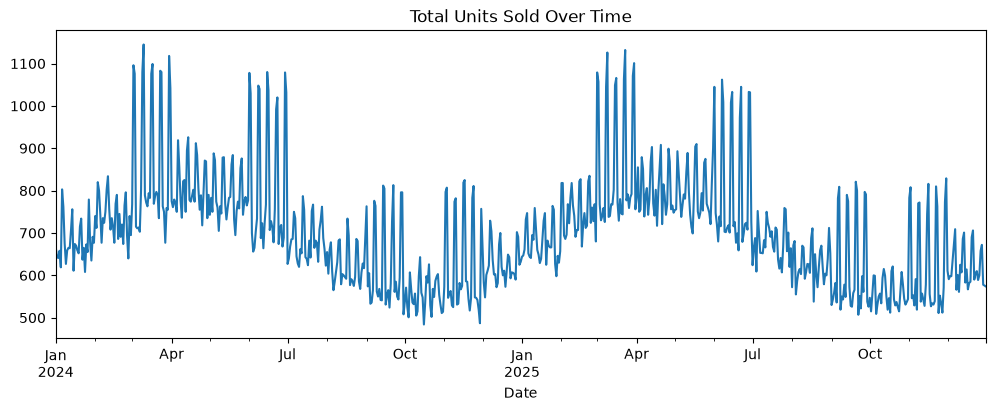

In [10]:
daily = fact_sales.groupby("Date")["Units_Sold"].sum()
daily.plot(figsize=(12,4), title="Total Units Sold Over Time")
plt.show()

### Key Insights

- Daily demand shows noticeable fluctuations over the two-year period rather than remaining constant.
- The variation suggests that demand is influenced by temporal and seasonal factors.
- These fluctuations reinforce the need for a time-series forecasting approach rather than relying only on historical average demand.
- For the forecasting model, calendar-based features such as **month, week, season, and year** are likely to be useful predictors.

**Monthly/seasonal pattern**

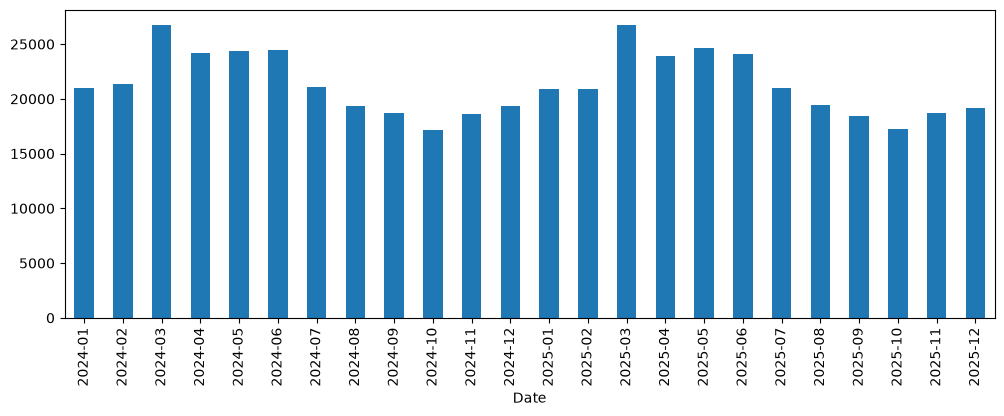

In [11]:
fact_sales.groupby(fact_sales["Date"].dt.to_period("M"))["Units_Sold"].sum().plot(kind="bar", figsize=(12,4))
plt.show()

### Key Insights

A clear repeating seasonal pattern is visible across both years of sales data, indicating that demand is not random.

- **March is the strongest demand period** in both years, with monthly sales exceeding approximately **26,000 units**.
- **April–June** maintains a relatively high-demand plateau, with monthly sales generally around **23,000–25,000 units**.
- Demand gradually declines during the middle and later part of the year.
- **September–October represents the annual low-demand period**, with October 2024 being the lowest month at approximately **17,000 units**.
- Demand begins recovering during **November–February**, eventually leading into the March peak.

Overall seasonal cycle:

**Sep–Oct trough → Nov–Feb recovery → March peak → Apr–Jun high demand → Jul–Oct decline**

### Business Implications

- Seasonality should be explicitly incorporated into the **D3 demand forecasting model**.
- The recurring March peak creates a potential period of **stockout risk** if inventory is not built up in advance.
- The September–October trough may create increased **overstock risk** if inventory levels remain at peak-season levels.
- The March peak should be investigated against promotion and holiday variables to determine whether it is driven primarily by recurring seasonality or specific events.

**Holiday or No holiday sales**

In [12]:
fact_sales.groupby("is_holiday")["Units_Sold"].mean()

is_holiday
0    14.023402
1    12.160000
Name: Units_Sold, dtype: float64

### Key Insights

- Average sales on regular days are approximately **14.02 units**, compared with **12.16 units on holidays**.
- Holiday demand is therefore approximately **13.3% lower** than non-holiday demand in this dataset.
- This suggests that holidays do not automatically translate into higher product demand.
- Holiday status should therefore be retained as a potential forecasting feature, but it should **not be assumed to have a positive effect on demand**.
- The impact may also vary by SKU or category, so further segmentation could determine whether certain products behave differently during holidays.

**Promotion or no promotion sales**

In [13]:
fact_sales['promotion_event'].unique()

<StringArray>
[nan, 'Seasonal Promotion']
Length: 2, dtype: str

In [14]:
fact_sales.groupby("promotion_event")["Units_Sold"].mean().sort_values(ascending=False)

promotion_event
Seasonal Promotion    18.613067
Name: Units_Sold, dtype: float64

### Key Insights

- The dataset contains a **Seasonal Promotion** event in addition to non-promotion observations.
- Average units sold during the Seasonal Promotion period are approximately **18.61 units**.
- Overall average demand is approximately **14.00 units**.
- This represents roughly a **32.9% increase in average units sold** during the Seasonal Promotion period compared with the overall average.
- Promotions therefore appear to be an important demand driver and should be incorporated into the forecasting model.
- Promotional periods may also increase **stockout risk**, making advance inventory planning particularly important.

**Top categories by revenue**

In [15]:
fact_sales['Category'].unique()

<StringArray>
['Furniture', 'Home Decor', 'Kitchen', 'Lighting', 'Storage']
Length: 5, dtype: str

In [16]:
fact_sales.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

Category
Home Decor    8.884681e+08
Furniture     6.033905e+08
Storage       5.819274e+08
Kitchen       5.635346e+08
Lighting      4.587362e+08
Name: Revenue, dtype: float64

### Key Insights

Total revenue across the five categories is approximately **₹3.10 billion**.

- **Home Decor** is the largest revenue-generating category at approximately **₹888.5 million**, contributing about **28.7%** of total revenue.
- **Furniture** contributes approximately **₹603.4 million (19.5%)**.
- **Storage** contributes approximately **₹581.9 million (18.8%)**.
- **Kitchen** contributes approximately **₹563.5 million (18.2%)**.
- **Lighting** generates approximately **₹458.7 million (14.8%)**.

### Business Implications

- Home Decor is the most important category from a revenue perspective and deserves particular attention in inventory planning.
- The remaining four categories have relatively substantial revenue contributions, meaning inventory optimization should not focus exclusively on the largest category.
- Category-level performance can be combined with SKU-level demand to identify products that contribute disproportionately to revenue or inventory risk.

**Top and Bottom SKU's**

In [17]:
fact_sales.groupby("SKU")["Units_Sold"].sum().sort_values(ascending=False).head(10)   # best sellers

SKU
SKU012    19067
SKU045    18612
SKU018    18450
SKU049    18373
SKU037    18155
SKU007    18129
SKU027    17717
SKU042    16616
SKU026    16535
SKU043    16276
Name: Units_Sold, dtype: int64

In [18]:
fact_sales.groupby("SKU")["Units_Sold"].sum().sort_values().head(10)  # worst sellers

SKU
SKU011    1951
SKU025    1976
SKU039    2300
SKU015    2994
SKU004    3380
SKU030    3493
SKU036    3508
SKU028    4101
SKU003    4214
SKU050    4537
Name: Units_Sold, dtype: int64

### Key Insights

The SKU-level analysis shows substantial differences in cumulative demand across products.

#### Top-performing SKUs

- **SKU012** is the strongest seller with approximately **19,067 units** sold.
- It is followed by **SKU045 (18,612)** and **SKU018 (18,450)**.
- The top SKUs represent products with consistently stronger demand and should receive higher priority in replenishment planning.
- These SKUs are potential **stockout-sensitive products**, particularly during seasonal peaks and promotional periods.

#### Bottom-performing SKUs

- **SKU011** has the lowest cumulative sales among the analyzed SKUs at approximately **1,951 units**.
- Other low-demand SKUs include **SKU025 (1,976)** and **SKU039 (2,300)**.
- These products may require closer monitoring for **overstock risk**, particularly during low-demand periods.
- Inventory decisions should therefore differentiate between high-velocity and low-velocity SKUs rather than applying the same replenishment strategy across the entire catalog.

**Margin sanity check**

In [19]:
fact_sales["Gross_Margin_Per_Unit"].describe()

count    36550.00000
mean      2121.93440
std       3746.89606
min      -5484.32000
25%       -681.48000
50%       1790.02500
75%       4923.44000
max      10224.93000
Name: Gross_Margin_Per_Unit, dtype: float64

### Key Insights

- Average gross margin per unit is approximately **₹2,121.93**.
- However, the minimum value is approximately **-₹5,484.32**, indicating that some observations have **negative gross margin**.
- The 25th percentile is also negative at approximately **-₹681.48**, meaning negative margins are not isolated to only one extreme observation.
- This requires further investigation because negative gross margins may indicate:
  - unusually low selling prices,
  - high product costs,
  - promotional discounting,
  - pricing/data-entry issues,
  - or other business rules affecting margin calculation.

### Data Quality Implication

Negative gross margins should **not automatically be treated as errors** without understanding the business logic. However, they should be flagged and investigated before using margin-based calculations for the D4 inventory risk and financial-impact analysis.

A useful next step is to examine negative-margin observations by **SKU, category, promotion status, price, and cost**.

# Overall EDA Conclusions

The exploratory analysis reveals several important demand and inventory patterns:

1. **Demand is highly variable** across SKU-date observations, making SKU-level forecasting more appropriate than using aggregate averages.
2. **Strong seasonality is present**, with March consistently representing a major demand peak and September–October representing a recurring low-demand period.
3. **Promotional activity has a significant demand impact**, with Seasonal Promotion observations showing approximately 33% higher average unit sales than the overall average.
4. **Holiday periods show lower average demand** in this dataset, so holiday effects should be modeled rather than assumed to increase sales.
5. **Revenue is concentrated to some extent in Home Decor**, which contributes approximately 28.7% of total revenue.
6. **SKU demand varies substantially**, creating different replenishment priorities for high-velocity and low-velocity products.
7. **Negative gross margins are present** and require further data-quality/business-rule investigation before financial impact calculations are finalized.

### Modeling Implications

These findings support using:

- **Seasonality and calendar features** for demand forecasting.
- **Promotion indicators** as demand drivers.
- **SKU-level forecasting** rather than only aggregate forecasting.
- **Historical demand patterns** to identify potential stockout and overstock periods.
- **Revenue and margin information** when translating inventory risks into financial impact.

The EDA therefore provides a strong foundation for the next stage: **D3 demand forecasting and D4 stockout/overstock risk scoring**.